In [1]:
import os
import sys
import yaml
import copy
import numpy as np
import pandas as pd
import xarray as xr

In [2]:
sys.path.insert(0, os.path.realpath('../libs/'))
import graph_utils as gu
#import verif_utils as vu

In [4]:
import cmaps
# graph tools
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import matplotlib.colors as colors
import matplotlib.colorbar as cbar
import matplotlib.ticker as ticker
from matplotlib.ticker import ScalarFormatter
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import cartopy.crs as ccrs
import cartopy.mpl.geoaxes
import cartopy.feature as cfeature

%matplotlib inline

In [5]:
dict_loc = {
    'Pituffik': (76.4, -68.575),
    'Fairbanks': (64.75, -147.4),
    'Guam': (13.475, 144.75),
    'Yuma_PG': (33.125, -114.125),
    'Fort_Bragg': (35.05, -79.115),
}

stn_names = list(dict_loc.keys())

In [6]:
def lon_to_0360(lon):
    return lon % 360.0

def subset_stn(ds_ACC_all: xr.Dataset, key: str, method: str = "nearest") -> xr.DataArray:
    sites = list(dict_loc.keys())
    lats = xr.DataArray([dict_loc[s][0] for s in sites], dims="site", coords={"site": sites})
    lons = xr.DataArray([lon_to_0360(dict_loc[s][1]) for s in sites], dims="site", coords={"site": sites})

    # result dims: (site, lead_year)
    return ds_ACC_all[key].sel(lat=lats, lon=lons, method=method)


In [7]:
scale_param = '110m'

PROVINCE = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale=scale_param,
    facecolor='none')

def map_gridline_opt(ax):
    '''
    Customize cartopy map gridlines
    '''
    ax.add_feature(cfeature.BORDERS.with_scale(scale_param), linestyle='-', linewidth=0.5, zorder=7)
    ax.add_feature(PROVINCE, edgecolor='k', linestyle='-', linewidth=0.5, zorder=7)
    ax.add_feature(cfeature.COASTLINE.with_scale(scale_param ), edgecolor='k', linewidth=0.5, zorder=5)
    ax.spines['geo'].set_linewidth(2.5)
    return ax

### PLOT

In [8]:
vmin, vmax = 0.0, 0.6
cmap = gu.precip_cmap(return_rgb=False, land_map=False)

In [13]:
fn = '/glade/derecho/scratch/ksha/EPRI_data/METRICS_GLOBE/CESM_minmax_10Y_ACC.zarr'
fn_detrend = '/glade/derecho/scratch/ksha/EPRI_data/METRICS_GLOBE/CESM_minmax_10Y_detrend_ACC.zarr'

ds_ACC_all = xr.open_zarr(fn)
ds_ACC_detrend = xr.open_zarr(fn_detrend)

x = ds_ACC_all['lon'].values
y = ds_ACC_all['lat'].values
lon, lat = np.meshgrid(x, y)

In [14]:
cmap = gu.precip_cmap(return_rgb=False, land_map=False)

my_colors = gu.ksha_color_set_summon(color_set=0)
cyan = np.array([0.4, 0.8, 1, 1])
blue = my_colors['blue']
red = my_colors['red']
orange = my_colors['orange']

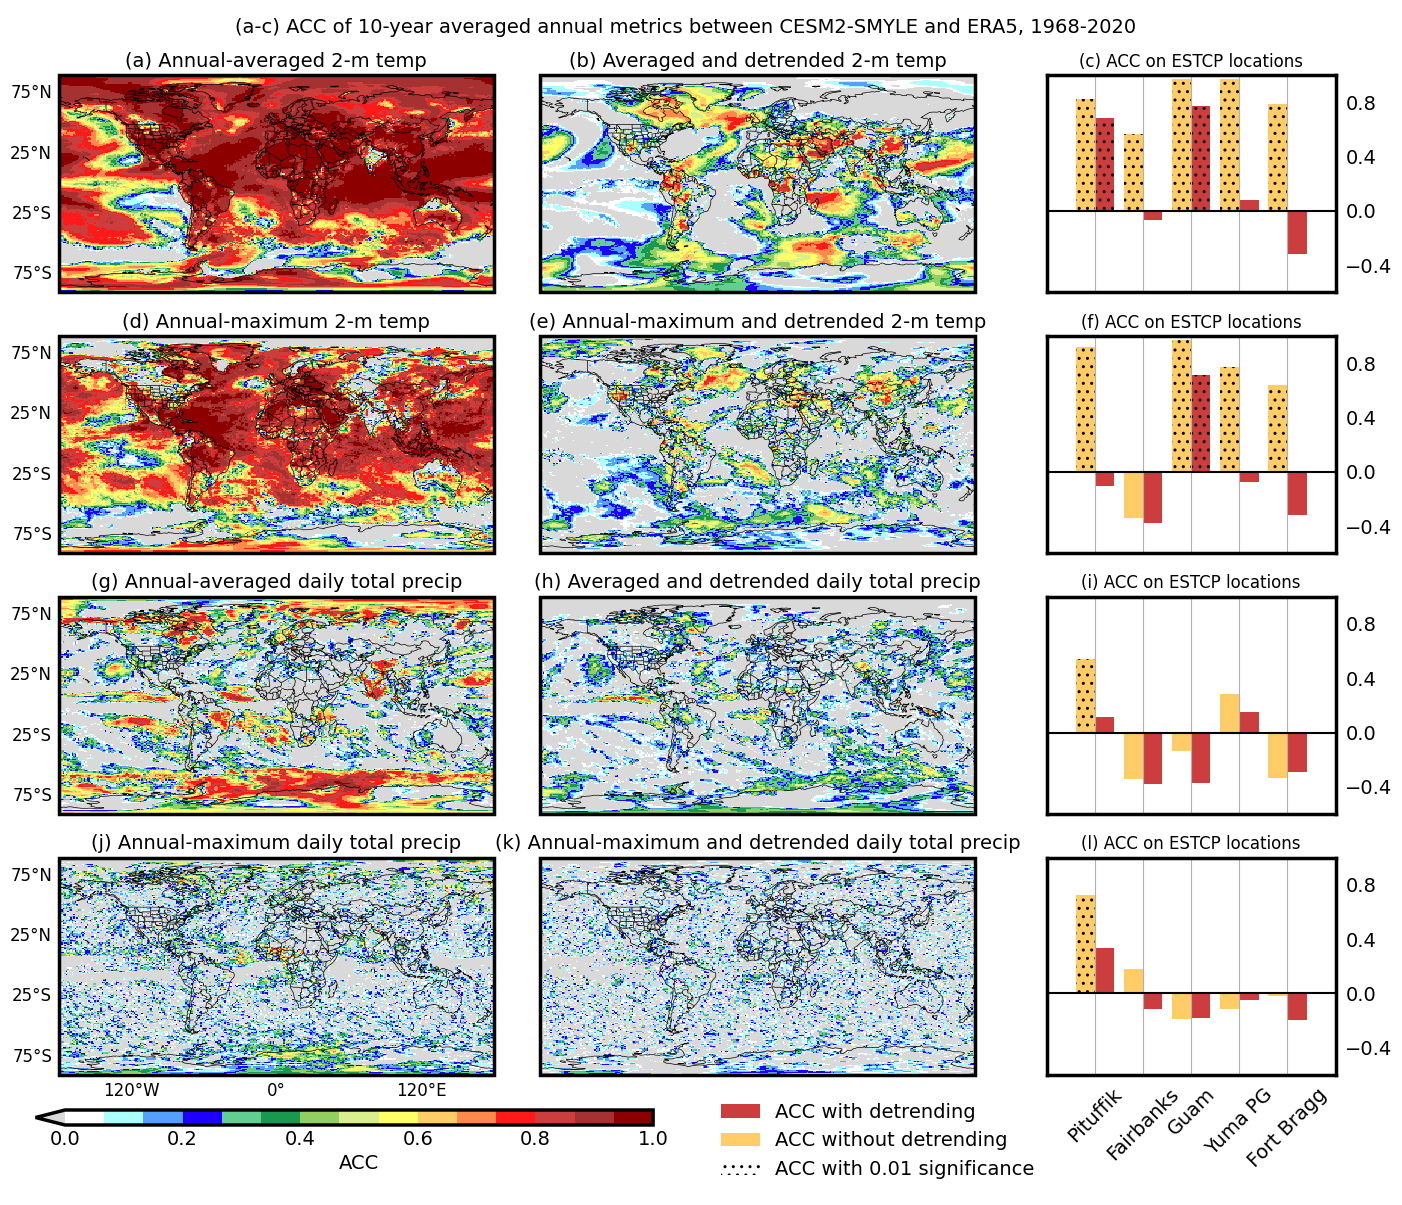

In [65]:
proj_ = ccrs.PlateCarree()
map_extent = [-180, 180, -90, 90]

fig = plt.figure(figsize=(13, 10))
gs = gridspec.GridSpec(4, 4, height_ratios=[1, 1, 1, 1], width_ratios=[1, 1, 0.1, 0.6])

AX_maps_norm = []
AX_maps_detrend = []
AX_lines = []

for i in range(4):
    AX_maps_norm.append(plt.subplot(gs[i, 0], projection=proj_))
    AX_maps_detrend.append(plt.subplot(gs[i, 1], projection=proj_))
    AX_lines.append(plt.subplot(gs[i, 3]))

fake_x = np.arange(5) # five stations
width = 0.40
x1 = fake_x - width/2   # left bars
x2 = fake_x + width/2   # right bars

for ax in AX_lines:
    ax = gu.ax_decorate_box(ax)
    ax.tick_params(labelright=True)
    ax.set_ylim([-0.6, 1])
    ax.set_yticks([-0.4, 0, 0.4, 0.8])
    ax.set_xlim(-1, fake_x[-1] + 1)
    ax.set_xticks(fake_x)
    ax.set_xticklabels(['Pituffik', 'Fairbanks', 'Guam', 'Yuma PG', 'Fort Bragg'], rotation=45)
    ax.grid(axis='x')

AX_lines[3].tick_params(labelbottom=True)

for i_ax, ax in enumerate(AX_maps_norm+AX_maps_detrend):
    ax.set_extent(map_extent, crs=proj_)
    ax = map_gridline_opt(ax)
    if i_ax in [0, 1, 2, 3]:
        GL = ax.gridlines(
            crs=ccrs.PlateCarree(),
            draw_labels=True, x_inline=False, y_inline=False,
            color='k', linewidth=0, linestyle=':', zorder=5
        )
        GL.top_labels = None
        GL.right_labels = None
        if i_ax in [0, 1, 2]:
            GL.bottom_labels = None
        GL.xlabel_style = {'size': 12}
        GL.ylabel_style = {'size': 12}
        GL.xlocator = ticker.FixedLocator([-120, 0, 120])
        GL.ylocator = ticker.FixedLocator([-75, -25, 25, 75])


plt.subplots_adjust(0, 0, 1, 1, hspace=0.2, wspace=0.0)



for i_key, key in enumerate(['TREFHT_mean', 'TREFHT_max', 'PRECT_mean', 'PRECT_max']):
    # ========================================================= #
    # access data per variable
    np_ACC = ds_ACC_all[key].values
    np_ACC_pval = ds_ACC_all[key+'_pval'].values
    np_ACC_detrend = ds_ACC_detrend[key+'_detrend'].values
    np_ACC_detrend_pval = ds_ACC_detrend[key+'_detrend_pval'].values
    
    ds_stn = subset_stn(ds_ACC_all, key=key)
    ds_stn_pval = subset_stn(ds_ACC_all, key=key+'_pval')
    ds_stn_detrend = subset_stn(ds_ACC_detrend, key=key+'_detrend')
    ds_stn_detrend_pval = subset_stn(ds_ACC_detrend, key=key+'_detrend_pval')
    
    np_stn = ds_stn.values
    np_stn_pval = ds_stn_pval.values
    np_stn_detrend = ds_stn_detrend.values
    np_stn_detrend_pval = ds_stn_detrend_pval.values

    # ========================================================== #
    # spatial maps
    CS = AX_maps_norm[i_key].pcolormesh(
        lon, lat, np_ACC, 
        vmin=0, vmax=1.0, cmap=cmap, 
        transform=ccrs.PlateCarree()
    )
    
    AX_maps_detrend[i_key].pcolormesh(
        lon, lat, np_ACC_detrend, 
        vmin=0, vmax=1.0, cmap=cmap, 
        transform=ccrs.PlateCarree()
    )
    # ========================================================== #
    # station-wise bar graphs

    # y=0 ref line
    AX_lines[i_key].axhline(0, xmin=0, xmax=1, linewidth=1.5, color='k', linestyle='-')
    
    bars1 = AX_lines[i_key].bar(x1, np_stn, width=width, color=orange, edgecolor="none")
    mask_pval = np_stn_pval < 0.01
    for rect, m in zip(bars1, mask_pval):
        if m:
            rect.set_hatch("..")
            rect.set_edgecolor("k")
            rect.set_linewidth(0.0)    
            
    bars2 = AX_lines[i_key].bar(x2, np_stn_detrend, width=width, color=red, edgecolor="none")
    mask_detrend_pval = np_stn_detrend_pval < 0.01
    for rect, m in zip(bars2, mask_detrend_pval):
        if m:
            rect.set_hatch("..")
            rect.set_edgecolor("k")
            rect.set_linewidth(0.0)

AX_maps_norm[0].set_title('(a) Annual-averaged 2-m temp', fontsize=14)
AX_maps_detrend[0].set_title('(b) Averaged and detrended 2-m temp', fontsize=14)
AX_lines[0].set_title('(c) ACC on ESTCP locations')

AX_maps_norm[1].set_title('(d) Annual-maximum 2-m temp', fontsize=14)
AX_maps_detrend[1].set_title('(e) Annual-maximum and detrended 2-m temp', fontsize=14)
AX_lines[1].set_title('(f) ACC on ESTCP locations')

AX_maps_norm[2].set_title('(g) Annual-averaged daily total precip', fontsize=14)
AX_maps_detrend[2].set_title('(h) Averaged and detrended daily total precip', fontsize=14)
AX_lines[2].set_title('(i) ACC on ESTCP locations')

AX_maps_norm[3].set_title('(j) Annual-maximum daily total precip', fontsize=14)
AX_maps_detrend[3].set_title('(k) Annual-maximum and detrended daily total precip', fontsize=14)
AX_lines[3].set_title('(l) ACC on ESTCP locations')

# 0.168 0.4
ax_base = fig.add_axes([0, -0.085, 0.475, 0.05])#
ax_base.tick_params(
    axis='both', left=False, top=False, right=False, bottom=False, 
    labelleft=False, labeltop=False, labelright=False, labelbottom=False
)
cax = inset_axes(ax_base, width='100%', height='30%', borderpad=0, loc=2)
CBar = plt.colorbar(CS, orientation='horizontal', extend='min', cax=cax) # ticks=[...]
CBar.ax.tick_params(axis='x', labelsize=14, direction='in', length=0)
CBar.outline.set_linewidth(2.5)
CBar.ax.set_xlabel('ACC', fontsize=14)

ax_title1 = fig.add_axes([0.0, 1.03, 1.0, 0.035])
ax_title1.text(
    0.5, 0.5, 
    '(a-c) ACC of 10-year averaged annual metrics between CESM2-SMYLE and ERA5, 1968-2020', 
    fontsize=14, va='center', ha='center', transform=ax_title1.transAxes
)

handle_legneds1 = []
handle_legneds1.append(patches.Patch(facecolor=red, linewidth=0, label=' '))
handle_legneds1.append(patches.Patch(facecolor=orange, linewidth=0, label=' '))
handle_legneds1.append(patches.Patch(facecolor='none', hatch='..', linewidth=0, label=' '))

ax_lg1 = fig.add_axes([0.512, -0.12, 0.27, 0.11])
LG1 = ax_lg1.legend(
    handle_legneds1, 
    ['ACC with detrending', 'ACC without detrending', 'ACC with 0.01 significance'], 
    bbox_to_anchor=(1, 1), ncol=1, prop={'size':14}
)

LG1 = gu.lg_box(LG1)
ax_lg1.set_axis_off()
ax_base.set_axis_off()
ax_title1.set_axis_off()